# BIOT 6900 · Module 4 Lab, Part 2: Real Predicted Structures

**Not graded · no GPU or cluster needed · needs an internet connection for the downloads (a few MB)**

In Part 1 you learned to read pLDDT and PAE, check a prediction against experiment, and judge pockets, on a toy protein. Now you do the **same steps on real AlphaFold models** of the course anchors:

| Protein | UniProt | Why it's here |
|---|---|---|
| p53 | P04637 | Confident core between disordered tails; experimental structure 1TUP; your Module 3 hotspots |
| APOE | P02649 | Helical lipid carrier; how sure is the arrangement of its parts? |
| TREM2 | Q9NZC2 | Cell-surface receptor with an Ig-like domain |

| Step | What you do |
|---|---|
| 2.1 | Download the AlphaFold models and PAE files |
| 2.2 | Read pLDDT for all three proteins |
| 2.3 | Read PAE and find the domains |
| 2.4 | Check the p53 prediction against the experimental structure 1TUP |
| 2.5 | Module 3 meets Module 4: your p53 hotspots in 3D |
| 2.6 | Pockets with fpocket (optional now; Mac/Linux, or the cluster next week) |
| 2.7 | Look at it in 3D (optional) |
| 2.8 | Check-in questions |

**ESMFold and Boltz-2** need a GPU. Those sections come next week on the Northeastern cluster; everything here runs on your laptop today.

**Run this in Jupyter** (not as a script), so plots appear under each cell.

In [1]:
import json, shutil, subprocess
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import urllib.request

STRUCT = Path("structures")
STRUCT.mkdir(exist_ok=True)
PROTEINS = {"TP53": "P04637", "APOE": "P02649", "TREM2": "Q9NZC2"}
BANDS = [(90, 101, "Very high", "#0053D6"), (70, 90, "Confident", "#65CBF3"),
         (50, 70, "Low", "#FFDB13"), (0, 50, "Very low", "#FF7D45")]
print("Ready. Files will be saved in:", STRUCT.resolve())

Ready. Files will be saved in: /Users/dhairyabhatia/BIOT6900/module4/structures


## 2.1 · Download the AlphaFold models and PAE files

The AlphaFold Database has a simple web API: ask for a UniProt accession, get back links to the model and its PAE file. Files are saved in `structures/` and **only downloaded once**.

**If a download fails** (campus firewall, site busy): open `https://alphafold.ebi.ac.uk/entry/P04637` in your browser, download the PDB file and the PAE JSON, and save them in `structures/` as `AF-P04637.pdb` and `AF-P04637-pae.json` (same pattern for the other two). Then re-run this cell.

In [2]:
def download(url, path):
    if path.exists() and path.stat().st_size > 0:
        return path
    req = urllib.request.Request(url, headers={"User-Agent": "BIOT6900-course-notebook"})
    with urllib.request.urlopen(req, timeout=60) as r:
        path.write_bytes(r.read())
    return path

def fetch_alphafold(acc):
    pdb_path, pae_path = STRUCT / f"AF-{acc}.pdb", STRUCT / f"AF-{acc}-pae.json"
    if pdb_path.exists() and pae_path.exists():
        return pdb_path, pae_path
    try:
        req = urllib.request.Request(f"https://alphafold.ebi.ac.uk/api/prediction/{acc}",
                                     headers={"User-Agent": "BIOT6900-course-notebook"})
        with urllib.request.urlopen(req, timeout=60) as r:
            entry = json.loads(r.read())[0]
        urls = [(entry["pdbUrl"], entry["paeDocUrl"])]
    except Exception as e:
        print(f"  API lookup failed for {acc} ({type(e).__name__}); trying direct file names")
        urls = []
    for v in ("v6", "v4"):   # fallbacks if the API is unavailable
        base = f"https://alphafold.ebi.ac.uk/files/AF-{acc}-F1"
        urls.append((f"{base}-model_{v}.pdb", f"{base}-predicted_aligned_error_{v}.json"))
    for pdb_url, pae_url in urls:
        try:
            download(pdb_url, pdb_path); download(pae_url, pae_path)
            return pdb_path, pae_path
        except Exception:
            continue
    raise RuntimeError(f"Could not download {acc}. Use the manual download described above.")

files = {}
for gene, acc in PROTEINS.items():
    files[gene] = fetch_alphafold(acc)
    print(f"{gene:6s} {acc}: {files[gene][0].name}, {files[gene][1].name}")

TP53   P04637: AF-P04637.pdb, AF-P04637-pae.json
APOE   P02649: AF-P02649.pdb, AF-P02649-pae.json
TREM2  Q9NZC2: AF-Q9NZC2.pdb, AF-Q9NZC2-pae.json


### Reading the files

A PDB file is plain text: one line per atom. AlphaFold stores **pLDDT in the B-factor column**, the same value for every atom of a residue. We read the C-alpha atom of each residue. The PAE file is JSON holding the full residue-by-residue matrix.

In [3]:
def read_pdb(path, chain=None):
    # Minimal fixed-column PDB reader: returns one row per atom.
    rows = []
    for line in open(path):
        if line.startswith(("ATOM", "HETATM")):
            ch = line[21]
            if chain and ch != chain:
                continue
            rows.append({"record": line[:6].strip(), "atom": line[12:16].strip(), "resname": line[17:20].strip(),
                         "chain": ch, "resnum": int(line[22:26]), "x": float(line[30:38]), "y": float(line[38:46]),
                         "z": float(line[46:54]), "b": float(line[60:66]) if line[60:66].strip() else 0.0,
                         "element": line[76:78].strip()})
        elif line.startswith("ENDMDL"):
            break                                  # first model only
    return pd.DataFrame(rows)

def load_pae(path):
    js = json.load(open(path))
    js = js[0] if isinstance(js, list) else js
    if "predicted_aligned_error" in js:
        return np.array(js["predicted_aligned_error"], dtype=float)
    n = int(max(js["residue1"]))                   # older format
    return np.array(js["distance"], dtype=float).reshape(n, n)

atoms, ca, pae = {}, {}, {}
for gene, (pdb_path, pae_path) in files.items():
    atoms[gene] = read_pdb(pdb_path)
    ca[gene] = atoms[gene][atoms[gene].atom == "CA"].reset_index(drop=True)
    pae[gene] = load_pae(pae_path)
    print(f"{gene:6s}: {len(ca[gene])} residues | PAE matrix {pae[gene].shape}")

TP53  : 393 residues | PAE matrix (393, 393)
APOE  : 317 residues | PAE matrix (317, 317)
TREM2 : 230 residues | PAE matrix (230, 230)


## 2.2 · Read pLDDT for all three proteins

Same bands and colours as Part 1. **Read stretches, not single bars**, and remember that low is information: often a disordered region.

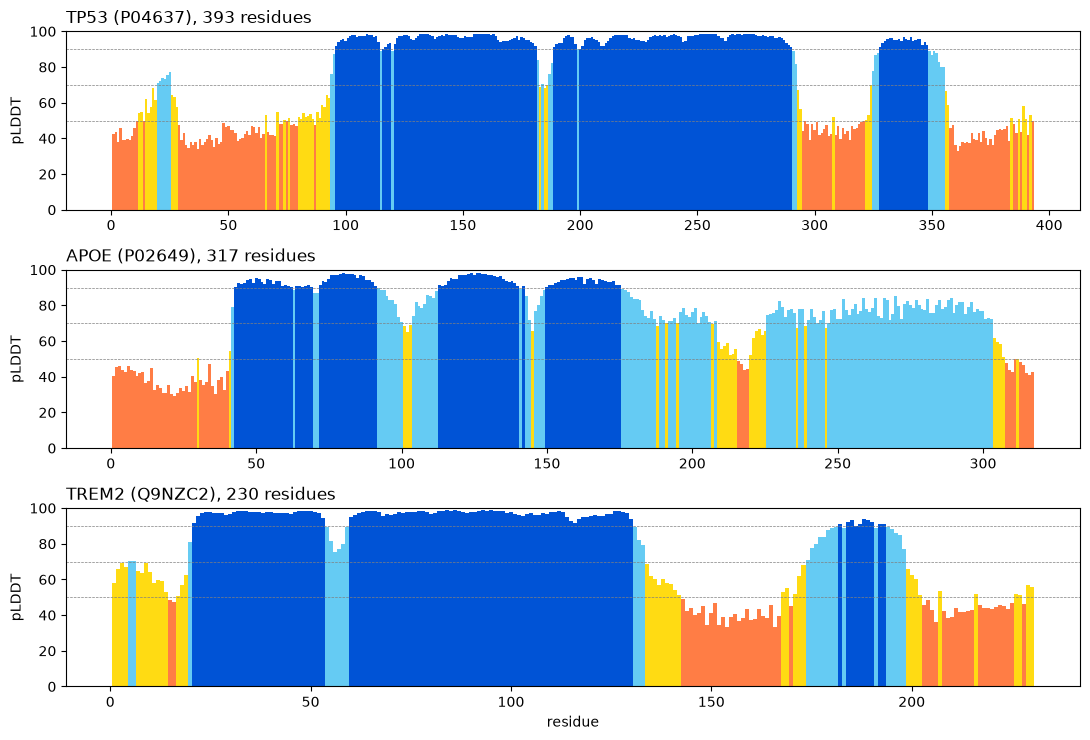

,protein,residues,mean pLDDT,% very high (>90),% very low (<50),stretches <50 (10+ residues)
0,TP53,393,75.1,52,30,"1–11, 29–65, 295–307, 309–321, 358–383"
1,APOE,317,75.5,32,16,"1–29, 31–40"
2,TREM2,230,76.8,50,22,143–167


In [4]:
def band(v):
    return "Very high" if v > 90 else "Confident" if v > 70 else "Low" if v > 50 else "Very low"
colour = {b[2]: b[3] for b in BANDS}

def runs_below(values, resnums, cut=50, min_len=10):
    out, start = [], None
    for i, flag in enumerate(np.append(values < cut, False)):
        if flag and start is None: start = i
        elif not flag and start is not None:
            if i - start >= min_len: out.append(f"{resnums[start]}–{resnums[i-1]}")
            start = None
    return ", ".join(out) or "none"

fig, axes = plt.subplots(3, 1, figsize=(11, 7.5))
summary = []
for ax, gene in zip(axes, PROTEINS):
    c = ca[gene]
    ax.bar(c.resnum, c.b, color=c.b.apply(band).map(colour), width=1.0)
    for y in (50, 70, 90): ax.axhline(y, color="grey", lw=0.5, ls="--")
    ax.set_ylim(0, 100); ax.set_ylabel("pLDDT"); ax.set_title(f"{gene} ({PROTEINS[gene]}), {len(c)} residues", loc="left")
    summary.append({"protein": gene, "residues": len(c), "mean pLDDT": round(c.b.mean(), 1),
                    "% very high (>90)": round((c.b > 90).mean() * 100), "% very low (<50)": round((c.b < 50).mean() * 100),
                    "stretches <50 (10+ residues)": runs_below(c.b.values, c.resnum.values)})
axes[-1].set_xlabel("residue"); plt.tight_layout(); plt.show()
pd.DataFrame(summary)

**Look for:** p53 should show a confident central block (the DNA-binding domain, roughly residues 94–292) with low-confidence stretches before and after it. Compare that with the lecture schematic (slide 9). Which protein has the largest fraction below 50? Which has the most very-high residues?

## 2.3 · Read PAE and find the domains

Same reading as Part 1: dark diagonal blocks are confident domains; pale off-diagonal blocks mean their **arrangement** is uncertain. The domain finder is the one from Part 1.

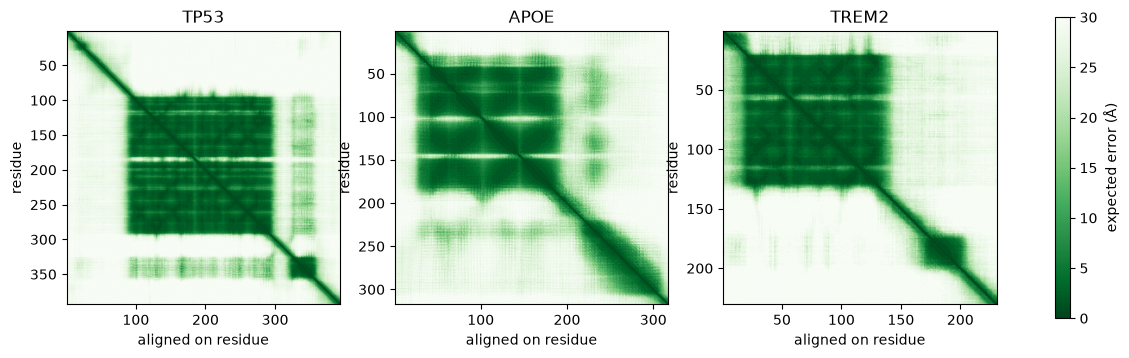


TP53: domains at PAE < 8 Å among confident residues
 start  end  confident residues
    94  292                 197
   324  355                  32

APOE: domains at PAE < 8 Å among confident residues
 start  end  confident residues
    42  208                 159
   226  303                  75

TREM2: domains at PAE < 8 Å among confident residues
 start  end  confident residues
    20  133                 114
   174  198                  25


In [5]:
def find_domains(pae, plddt, pae_cut=8, min_size=20):
    ok = np.where(plddt >= 70)[0]
    sub = pae[np.ix_(ok, ok)]
    linked = (sub < pae_cut) & (sub.T < pae_cut)
    label, cur = -np.ones(len(ok), int), 0
    for s0 in range(len(ok)):
        if label[s0] >= 0: continue
        stack = [s0]; label[s0] = cur
        while stack:
            k = stack.pop()
            for m in np.where(linked[k] & (label < 0))[0]:
                label[m] = cur; stack.append(m)
        cur += 1
    out = []
    for c_ in range(cur):
        mem = ok[label == c_] + 1
        if len(mem) >= min_size: out.append((mem.min(), mem.max(), len(mem)))
    return pd.DataFrame(out, columns=["start", "end", "confident residues"])

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
for ax, gene in zip(axes, PROTEINS):
    n = pae[gene].shape[0]
    im = ax.imshow(pae[gene], cmap="Greens_r", vmin=0, vmax=30, extent=[0.5, n + 0.5, n + 0.5, 0.5])
    ax.set_title(gene); ax.set_xlabel("aligned on residue"); ax.set_ylabel("residue")
plt.colorbar(im, ax=axes, label="expected error (Å)", shrink=0.85); plt.show()

PAE_CUT = 8        # ✎ try other values, as in Part 1
for gene in PROTEINS:
    print(f"\n{gene}: domains at PAE < {PAE_CUT} Å among confident residues")
    print(find_domains(pae[gene], ca[gene].b.values, PAE_CUT).to_string(index=False))

**Look for:** how many confident domains does each protein have? For any protein with two or more, is the off-diagonal block between them dark (arrangement confident) or pale (uncertain)? Apply the slide 12 decision table: which regions would you trust for pocket analysis?

## 2.4 · Check the p53 prediction against 1TUP

**1TUP** is the p53 DNA-binding domain crystallised with DNA (you met it in Module 1). It contains three p53 chains (A, B, C), two DNA strands, and zinc ions. We compare **chain B** with the AlphaFold model, using only residues present in both, and then only confident ones (the rule from Part 1).

In [6]:
exp_path = download("https://files.rcsb.org/download/1TUP.pdb", STRUCT / "1TUP.pdb")
exp_all = read_pdb(exp_path)
exp_b = exp_all[(exp_all.chain == "B") & (exp_all.record == "ATOM")]
exp_ca = exp_b[exp_b.atom == "CA"].drop_duplicates("resnum").set_index("resnum")
zinc = exp_all[(exp_all.resname == "ZN")]
dna = exp_all[exp_all.resname.isin(["DA", "DC", "DG", "DT", "A", "C", "G", "T"])]
print(f"1TUP chain B: residues {exp_ca.index.min()}–{exp_ca.index.max()} ({len(exp_ca)} with C-alpha)")
print(f"Zinc ions in the crystal: {len(zinc)} | DNA atoms: {len(dna)}")
print("Neither zinc nor DNA is in the AlphaFold model, which is a single protein chain.")

def kabsch(P, Q):
    # Optimal rotation R and translation so that P @ R + t matches Q; returns R, t, rmsd
    Pc, Qc = P.mean(0), Q.mean(0)
    U, S, Vt = np.linalg.svd((P - Pc).T @ (Q - Qc))
    d = np.sign(np.linalg.det(U @ Vt))
    R = U @ np.diag([1, 1, d]) @ Vt
    rmsd = float(np.sqrt((((P - Pc) @ R - (Q - Qc)) ** 2).sum(1).mean()))
    return R, Qc - Pc @ R, rmsd

af = ca["TP53"].set_index("resnum")
common = sorted(set(af.index) & set(exp_ca.index))
confident = [r for r in common if af.loc[r, "b"] >= 70]
xyz = lambda df, rs: df.loc[rs, ["x", "y", "z"]].to_numpy()
R, t, rmsd_all = kabsch(xyz(af, common), xyz(exp_ca, common))
R, t, rmsd_conf = kabsch(xyz(af, confident), xyz(exp_ca, confident))
print(f"\nRMSD over all {len(common)} common residues: {rmsd_all:.2f} Å")
print(f"RMSD over {len(confident)} confident common residues (pLDDT >= 70): {rmsd_conf:.2f} Å")

1TUP chain B: residues 96–289 (194 with C-alpha)
Zinc ions in the crystal: 3 | DNA atoms: 855
Neither zinc nor DNA is in the AlphaFold model, which is a single protein chain.

RMSD over all 194 common residues: 0.73 Å
RMSD over 192 confident common residues (pLDDT >= 70): 0.68 Å


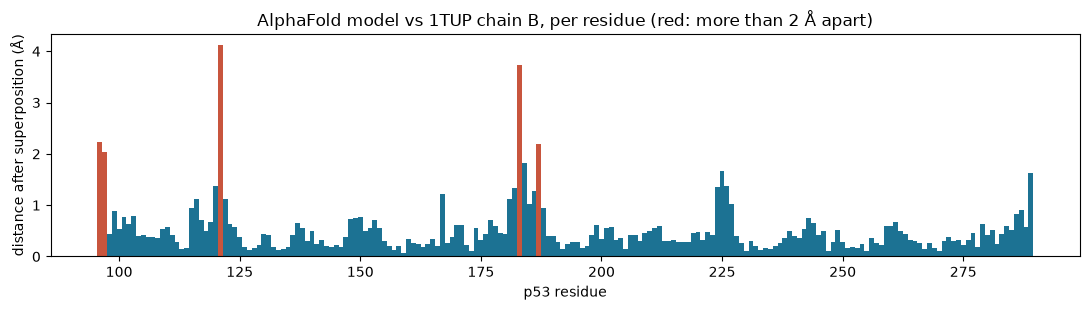

Residues that differ most:
121    4.12
183    3.74
96     2.24
187    2.20
97     2.03
184    1.83
225    1.66
289    1.63


In [7]:
# Where do they differ? Per-residue distance after superposing on the confident residues
moved = xyz(af, common) @ R + t
dev = pd.Series(np.linalg.norm(moved - xyz(exp_ca, common), axis=1), index=common, name="deviation_A")

fig, ax = plt.subplots(figsize=(11, 3.2))
ax.bar(dev.index, dev.values, color=["#C8553D" if d > 2 else "#1C7293" for d in dev.values], width=1.0)
ax.set_xlabel("p53 residue"); ax.set_ylabel("distance after superposition (Å)")
ax.set_title("AlphaFold model vs 1TUP chain B, per residue (red: more than 2 Å apart)"); plt.tight_layout(); plt.show()
print("Residues that differ most:"); print(dev.nlargest(8).round(2).to_string())

**Look for:** is the RMSD over confident residues close to the 1–2 Å "very close" range from lecture slide 17? Where are the largest deviations: in the core, or in surface loops, some of which touch DNA in the crystal? Remember the crystal has DNA and zinc bound; the prediction has neither.

## 2.5 · Module 3 meets Module 4: your p53 hotspots in 3D

In Module 3 the language model, with **no structure**, found positions 176, 238 and 242 among p53's least tolerated, and scored the cancer hotspots as damaging. Now measure, in the real crystal structure, how close each position is to the **zinc** and to the **DNA**.

In [8]:
HOTSPOTS = [175, 176, 179, 220, 238, 242, 245, 248, 249, 273, 282]   # ✎ add positions you care about

def min_dist(res_atoms, target):
    if len(res_atoms) == 0 or len(target) == 0:
        return np.nan
    A = res_atoms[["x", "y", "z"]].to_numpy(); B = target[["x", "y", "z"]].to_numpy()
    return float(np.sqrt(((A[:, None, :] - B[None, :, :]) ** 2).sum(-1)).min())

rows = []
for r in HOTSPOTS:
    side = exp_b[(exp_b.resnum == r) & ~exp_b.atom.isin(["N", "C", "O"])]
    d_zn, d_dna = min_dist(side, zinc), min_dist(side, dna)
    role = ("zinc ligand" if d_zn < 3.0 else "DNA contact" if d_dna < 4.5 else
            "near DNA" if d_dna < 8 else "structural / other")
    rows.append({"residue": r, "aa": side.resname.iloc[0] if len(side) else "?",
                 "AlphaFold pLDDT": round(af.loc[r, "b"], 1) if r in af.index else np.nan,
                 "min dist to zinc (Å)": round(d_zn, 1), "min dist to DNA (Å)": round(d_dna, 1), "role in 1TUP": role})
hot = pd.DataFrame(rows)
hot

,residue,aa,AlphaFold pLDDT,min dist to zinc (Å),min dist to DNA (Å),role in 1TUP
0,175,ARG,96.6,5.3,13.2,structural / other
1,176,CYS,96.5,2.3,10.8,zinc ligand
2,179,HIS,94.2,2.1,8.2,zinc ligand
3,220,TYR,97.7,29.0,29.8,structural / other
4,238,CYS,97.2,2.2,8.6,zinc ligand
5,242,CYS,97.4,2.2,7.2,zinc ligand
6,245,GLY,94.8,6.1,11.1,structural / other
7,248,ARG,97.2,10.6,3.4,DNA contact
8,249,ARG,97.8,11.3,7.2,near DNA
9,273,ARG,98.6,12.9,2.5,DNA contact


**Look for:** which positions are zinc ligands, which touch DNA, and which do neither? Where does **Y220** sit, the hotspot that scored least extreme in Module 3 and whose mutant opens a druggable crevice? (Lecture slide 23.) All of these residues are in the confident core of the AlphaFold model: is that consistent with them being functionally critical?

## 2.6 · Pockets with fpocket (optional today)

fpocket finds pockets from geometry and gives each a druggability score. It installs on **Mac and Linux** with one command; **Windows users** run it on the Northeastern cluster next week. If fpocket isn't installed, this cell explains how and skips; nothing else depends on it.

```
conda activate biot6900
conda install -c conda-forge fpocket
```

We run it on the full p53 model and then apply the **Part 1 confidence rules** to every pocket: reject if the lining residues have mean pLDDT below 70; suspect if the PAE among them is above 10 Å.

In [9]:
def run_fpocket(pdb_path):
    out_dir = pdb_path.parent / f"{pdb_path.stem}_out"
    if not out_dir.exists():
        subprocess.run(["fpocket", "-f", str(pdb_path)], check=True, capture_output=True)
    info = (out_dir / f"{pdb_path.stem}_info.txt").read_text()
    pockets, cur = [], None
    for line in info.splitlines():
        if line.startswith("Pocket"):
            cur = {"pocket": int(line.split()[1])}; pockets.append(cur)
        elif cur is not None and ":" in line:
            key, val = [s.strip() for s in line.split(":", 1)]
            if key in ("Score", "Druggability Score", "Volume"):
                cur[key] = float(val)
    for p in pockets:
        lining = read_pdb(out_dir / "pockets" / f"pocket{p['pocket']}_atm.pdb")
        p["lining_residues"] = sorted(lining.resnum.unique().tolist())
    return pd.DataFrame(pockets)

if shutil.which("fpocket") is None:
    pockets = None
    print("fpocket is not installed, so this step is skipped for now.\n"
          "Mac/Linux: conda install -c conda-forge fpocket, then Kernel > Restart and re-run.\n"
          "Windows: you'll run this on the Northeastern cluster next week.")
else:
    pockets = run_fpocket(files["TP53"][0])
    plddt53 = af["b"]; P = pae["TP53"]
    def check(lining):
        idx = [r for r in lining if r in plddt53.index]
        mp = plddt53.loc[idx].mean()
        pe = P[np.ix_(np.array(idx) - 1, np.array(idx) - 1)].mean()
        verdict = ("reject: low confidence" if mp < 70 else
                   "suspect: lining not placed together" if pe > 10 else "keep")
        return pd.Series({"mean_pLDDT": round(mp, 1), "PAE_within": round(pe, 1), "verdict": verdict,
                          "span": f"{min(idx)}–{max(idx)}"})
    pockets = pd.concat([pockets, pockets.lining_residues.apply(check)], axis=1)
    show = ["pocket", "Druggability Score", "Volume", "span", "mean_pLDDT", "PAE_within", "verdict"]
    print("Top 10 p53 pockets by druggability score:")
    display(pockets.sort_values("Druggability Score", ascending=False)[show].head(10))

Top 10 p53 pockets by druggability score:


,pocket,Druggability Score,Volume,span,mean_pLDDT,PAE_within,verdict
26,27,0.363,258.300,49–54,43.9,2.9,reject: low confidence
18,19,0.087,611.723,326–349,93.2,1.6,keep
15,16,0.062,177.097,98–267,97.8,1.2,keep
19,20,0.053,152.530,340–344,96.0,0.7,keep
6,7,0.041,231.897,39–43,39.0,2.4,reject: low confidence
0,1,0.018,448.401,145–233,95.8,1.7,keep
11,12,0.016,313.871,273–357,90.8,6.6,keep
22,23,0.009,522.086,288–353,87.8,7.6,keep
2,3,0.007,590.567,138–237,92.4,2.8,keep
8,9,0.006,330.113,40–45,39.0,2.9,reject: low confidence


**Look for (if you ran it):** how many high-scoring pockets sit in the low-confidence tails and get rejected, exactly as P3 did in the toy? Do any confident pockets sit near Y220? Remember: the Y220C crevice only forms in the **mutant**, so a wild-type model shouldn't show it. That is the "mutant pockets" limit from the lecture.

## 2.7 · Look at it in 3D (optional)

An interactive view of the p53 model coloured by pLDDT (blue confident, orange/red low), with the hotspots shown as sticks. Needs the small `py3Dmol` package (`pip install py3Dmol`) and an internet connection to draw.

In [10]:
try:
    import py3Dmol
    view = py3Dmol.view(width=700, height=480)
    view.addModel(open(files["TP53"][0]).read(), "pdb")
    view.setStyle({"cartoon": {"colorscheme": {"prop": "b", "gradient": "roygb", "min": 50, "max": 90}}})
    view.addStyle({"resi": [str(r) for r in HOTSPOTS]}, {"stick": {"colorscheme": "magentaCarbon"}})
    view.zoomTo({"resi": "94-292"})
    view.show()
except ImportError:
    print("py3Dmol not installed: pip install py3Dmol, then re-run. "
          "Or view the model at https://alphafold.ebi.ac.uk/entry/P04637")

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## 2.8 · Check-in (not graded)

Answer briefly in the cell below:

1. Which of the three proteins is most disordered by pLDDT, and what does that mean for looking for drug pockets in it?
2. What RMSD did you get between the AlphaFold model and 1TUP over confident residues, and where were the biggest differences?
3. In your hotspot table, which residues are zinc ligands and which touch DNA? How does that connect to your Module 3 variant scores?
4. (If you ran fpocket) How many top pockets did the confidence rules reject?

**Next week on the cluster:** ESMFold on the same proteins, and a Boltz-2 protein–ligand complex.

*Your answers:*